# Lanzar simulaciones desde pp_reset

Flujo equivalente a `Lanzar_simulacion_RRAM.ipynb` pero el ciclo arranca en **PP_reset**.

```
init  →  generar_estados_sp_set  →  exec --start-from pp_reset  →  plot
```

La sección **3 · Generar estados sp_set** sustituye a la ejecución de PP_set + SP_set:
crea un `actual_state` percolante para cada simulación y lo guarda en
`Init_data/phase_state_{n_save}_sp_set.*`.

Logging: nivel global por env var `RRAM_LOG_LEVEL=DEBUG|INFO|WARNING`.
Cada subprocess escribe `logs/log_simulacion_{N}.log`.

In [2]:
%load_ext autoreload
%autoreload 2

import concurrent.futures
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RRAM import simulation_config, Percolation, utils
from RRAM.init_simulation import load_simulation_config
from RRAM.persistence import save_phase_state

ruta_raiz = Path.cwd()
print('Ruta raíz del proyecto:', ruta_raiz)


Ruta raíz del proyecto: /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation


## 0 · Estructura de carpetas


In [26]:
def setup_project_structure():
    for folder in ['Init_data', 'Results', 'Results/Figures', 'logs']:
        Path(folder).mkdir(parents=True, exist_ok=True)
        print(f'OK carpeta: {folder}/')

setup_project_structure()

carpeta_results = ruta_raiz / 'Results'
if carpeta_results.exists():
    shutil.rmtree(carpeta_results)
carpeta_results.mkdir(parents=True, exist_ok=True)
(carpeta_results / 'Figures').mkdir(parents=True, exist_ok=True)

log_dir = ruta_raiz / 'logs'
log_dir.mkdir(exist_ok=True)
for f in log_dir.iterdir():
    if f.is_file():
        try:
            f.unlink()
        except Exception as e:
            print(f'No se pudo eliminar {f}: {e}')

print('Estructura lista.')


OK carpeta: Init_data/
OK carpeta: Results/
OK carpeta: Results/Figures/
OK carpeta: logs/
Estructura lista.


## 1 · Generación de parámetros (CSV → Init_data)


In [27]:
manager = simulation_config.ConfigManager()
carpeta_init = 'Init_data'

# ── Ajusta el barrido según tu experimento ───────────────────────────────
parametros_barrido = {
    # "num_filamentos": [1,1,1,1,1],
    # "grosor_filamento": [[30], [30], [30], [30], [30]],
    "device_size_y": [20e-9, 25e-9, 30e-9, 35e-9, 40e-9],
    # "num_trampas": [20,20,20,20,20],
}
# ─────────────────────────────────────────────────────────────────────────

manager.add_zip(zip_params=parametros_barrido)
manager.export_to_init_data(carpeta_init)

num_simulaciones = len(manager.simulations)
num_filamentos = int(manager.simulations[0].params.get('num_filamentos', 2))
print(f"Generadas {num_simulaciones} configuraciones en {carpeta_init}/.")
print(f"num_filamentos por simulación: {num_filamentos}")


Generadas 5 configuraciones en Init_data/.
num_filamentos por simulación: 1


## 2 · INIT — pre-generar estados iniciales

Genera `Init_data/init_state_{i}.npz` para cada simulación del CSV.


In [28]:
resultado = subprocess.run(
    [sys.executable, '-m', 'RRAM', 'init'],
    cwd=str(ruta_raiz),
    capture_output=True, text=True,
)
print(resultado.stdout)
if resultado.returncode != 0:
    print('STDERR:', resultado.stderr)
    raise RuntimeError('init falló')


## 3 · Generar estados sp_set

Para cada simulación construimos el dict `final_state_sp_set` que necesita `PP_reset`
y lo guardamos en `Init_data/phase_state_{n_save}_sp_set.*`.

El dispositivo se inicializa en **LRS**: se parte del `init_state_N.npz` y se añade
una franja de vacantes continua en la zona de cada filamento para garantizar la
percolación. El perfil de temperatura se fija uniformemente a `params.init_temp`.


In [29]:
def crear_franja_percolante(
    state: np.ndarray,
    cf_ranges: list,
    cf_centros: list,
    grosor_filamento,
) -> np.ndarray:
    state = state.copy()
    for idx, (row_min, row_max) in enumerate(cf_ranges):
        centro = cf_centros[idx]
        if isinstance(grosor_filamento, (list, tuple, np.ndarray)):
            grosor = int(grosor_filamento[idx]) if idx < len(grosor_filamento) else int(grosor_filamento[-1])
        else:
            grosor = int(grosor_filamento)
        mitad    = grosor // 2
        fila_ini = max(row_min, centro - mitad)
        fila_fin = min(row_max + 1, centro + mitad + 1)
        state[fila_ini:fila_fin, :] = True
    return state


def generar_estado_sp_set(
    num_simulation: int,
    init_data_dir: Path = Path('Init_data'),
    tiempo_sp_set: float = 0.0,
) -> bool:
    """
    Construye y guarda el estado final de SP_set para una simulación concreta.

    Returns:
        True si el dispositivo percola al final; False en caso contrario.
    """
    cfg      = load_simulation_config(num_simulation, init_data_dir=init_data_dir)
    params   = cfg.params
    sim_ctes = cfg.sim_ctes
    n_save   = num_simulation + 1

    eje_x = params.y_size
    eje_y = params.x_size

    init_path    = init_data_dir / f'init_state_{num_simulation}'
    actual_state = utils.cargar_estado(init_path).astype(bool)

    actual_state = crear_franja_percolante(
        actual_state,
        cf_ranges=cfg.cf_ranges,
        cf_centros=cfg.cf_centros,
        grosor_filamento=sim_ctes.grosor_filamento,
    )

    percola = Percolation.is_path(actual_state.astype(int))

    Temperatura_final = np.full(
        (eje_x, eje_y + 2),
        fill_value=float(params.init_temp),
        dtype=np.float64,
    )

    final_state_sp_set = {
        'actual_state'      : actual_state,
        'sim_ctes'          : sim_ctes,
        'params'            : params,
        'Temperatura_final' : Temperatura_final,
        'percola'           : percola,
        'centros_calculados': list(cfg.cf_centros),
        'tiempo_sp_set'     : tiempo_sp_set,
    }

    save_phase_state(
        state_dict     = final_state_sp_set,
        phase_name     = 'sp_set',
        num_simulation = n_save,
        init_data_dir  = init_data_dir,
    )
    return percola


In [30]:
init_data_dir = Path('Init_data')
errores_percola = []

for num_sim in range(num_simulaciones):
    percola = generar_estado_sp_set(num_sim, init_data_dir=init_data_dir)
    estado  = '✓ percola' if percola else '⚠ NO percola'
    print(f'  sim {num_sim:3d} (n_save={num_sim+1:3d}): {estado}')
    if not percola:
        errores_percola.append(num_sim)

print(f'\nEstados sp_set generados: {num_simulaciones}')
if errores_percola:
    print(f'⚠  Simulaciones sin percolación: {errores_percola}')
    print('   Revisa el grosor_filamento o los rangos de CF para esas configuraciones.')
else:
    print('Todas las simulaciones percolan correctamente.')


  sim   0 (n_save=  1): ✓ percola
  sim   1 (n_save=  2): ✓ percola
  sim   2 (n_save=  3): ✓ percola
  sim   3 (n_save=  4): ✓ percola
  sim   4 (n_save=  5): ✓ percola

Estados sp_set generados: 5
Todas las simulaciones percolan correctamente.


## 4 · EXEC desde pp_reset — lanzamiento paralelo

Cada simulación es un subprocess `python -m RRAM exec <num> --start-from pp_reset`.
Lee el estado guardado en `Init_data/phase_state_{n_save}_sp_set.*` y ejecuta
PP_reset + SP_reset directamente.


In [31]:
# ── Configuración de ejecución ────────────────────────────────────────────
log_level        = os.environ.get('RRAM_LOG_LEVEL', 'INFO')
num_procesadores = max(int(0.1 * (os.cpu_count() or 10)), 1)
# ─────────────────────────────────────────────────────────────────────────

sims_a_ejecutar = [n for n in range(num_simulaciones) if n not in errores_percola]
print(
    f'Lanzando {len(sims_a_ejecutar)} simulaciones desde pp_reset '
    f'con {num_procesadores} procesadores. RRAM_LOG_LEVEL={log_level}'
)


def ejecutar_desde_pp_reset(num_simulacion: int) -> int:
    env = os.environ.copy()
    env['RRAM_LOG_LEVEL'] = log_level

    cmd = [
        sys.executable, '-m', 'RRAM', 'exec',
        str(num_simulacion),
        '--start-from', 'pp_reset',
    ]
    print(f'  Iniciando exec sim={num_simulacion + 1} (desde pp_reset)')
    completed = subprocess.run(cmd, cwd=str(ruta_raiz), env=env)
    if completed.returncode != 0:
        print(f'  AVISO: sim {num_simulacion + 1} terminó con código {completed.returncode}')
    return completed.returncode


start_time = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=num_procesadores) as executor:
    list(executor.map(ejecutar_desde_pp_reset, sims_a_ejecutar))
elapsed_h = (time.time() - start_time) / 3600

print(f'\nTodas las simulaciones han terminado.')
print(f'Tiempo total: {elapsed_h:.2f} h ({elapsed_h * 3600:.1f} s)')


Lanzando 5 simulaciones desde pp_reset con 1 procesadores. RRAM_LOG_LEVEL=INFO
  Iniciando exec sim=1 (desde pp_reset)
  Iniciando exec sim=2 (desde pp_reset)
  Iniciando exec sim=3 (desde pp_reset)
  Iniciando exec sim=4 (desde pp_reset)
  Iniciando exec sim=5 (desde pp_reset)

Todas las simulaciones han terminado.
Tiempo total: 0.71 h (2554.8 s)


In [32]:
# Notificación WhatsApp (opcional)
import urllib.parse
import requests

def enviar_notificacion_whatsapp(n_sims, tiempo_total):
    telefono = "+34689866027"
    apikey   = "2486810"
    mensaje  = f"✅ Simulaciones RRAM (desde pp_reset) completadas. Procesadas: {n_sims} en {tiempo_total:.2f}h."
    url = f"https://api.callmebot.com/whatsapp.php?phone={telefono}&text={urllib.parse.quote(mensaje)}&apikey={apikey}"
    try:
        requests.get(url, timeout=10)
    except Exception as e:
        print(f'Notificación no enviada: {e}')

enviar_notificacion_whatsapp(len(sims_a_ejecutar), elapsed_h)


## 5 · Perfil de temperatura


Perfil de temperatura para sim 5, paso 7100, columna 20:
[306.97011788 306.99111797 307.03324466 307.1177518  307.24514846
 307.41620206 307.63194301 307.89367086 308.20296212 308.56167974
 308.97198427 309.43634684 309.95756394 310.53877425 311.18347736
 311.89555476 312.67929303 313.53940941 314.48107999 315.50997045
 316.63226979 317.85472701 319.18469102 320.63015399 322.19979834
 323.90304752 325.75012096 327.75209327 329.92095799 332.26969612
 334.81234963 337.56410018 340.54135316 343.76182727 347.24464958
 351.0104562  355.08149834 359.48175356 364.23704175 369.3751453
 374.92593232 380.92148208 387.39621064 394.38699492 401.93329257
 410.07725445 418.86382612 428.34083385 438.55905038 449.57223476
 461.43714057 474.2134865  487.96388351 502.75371319 518.65095298
 535.72594483 554.05110431 573.70056634 594.74975834 617.27487577
 641.35219316 667.05703063 694.46187145 723.63210353 741.49852002
 745.89243846 749.93617584 753.63849099 757.00861415 760.05561246
 762.78812292 765.21

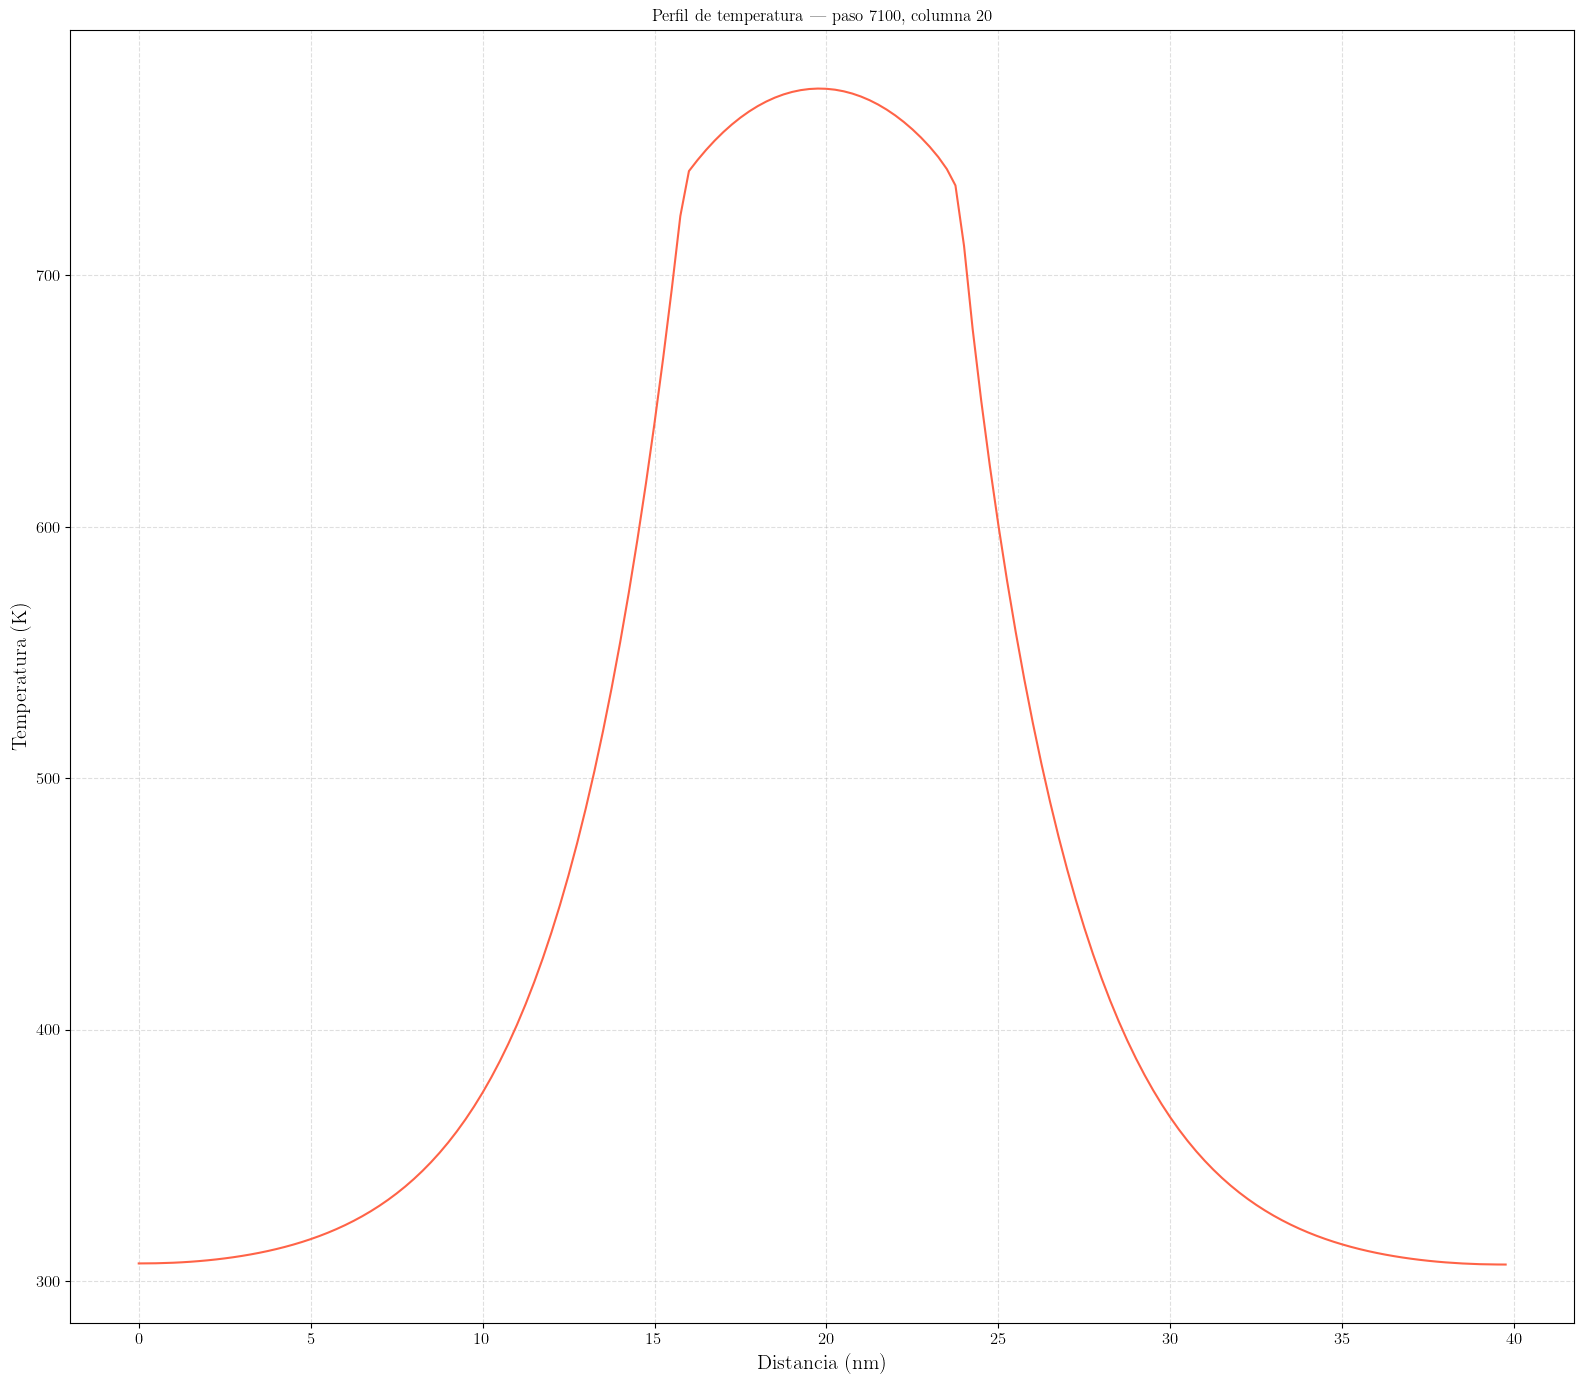

In [10]:
# ── Configura aquí ───────────────────────────────────────────────────────
n_save  = 5     # número de simulación (= num_simulacion + 1)
paso    = 7100  # paso guardado
columna = 20    # columna del dispositivo (0-based, sin contar bordes)
# ─────────────────────────────────────────────────────────────────────────

ruta_npz = (
    Path('Results')
    / f'simulation_{n_save}'
    / 'reset'
    / f'Estado_pp_reset_sim_{n_save}_paso_{paso}.npz'
)

if not ruta_npz.is_file():
    raise FileNotFoundError(f'No se encontró: {ruta_npz}')

data        = np.load(ruta_npz)
temperatura = data['temperatura']   # shape (eje_x, eje_y + 2)

if temperatura.ndim != 2 or temperatura.size == 0:
    raise ValueError('temperatura no disponible en este paso (sin percolación).')

# columna del dispositivo → índice en la matriz (+1 por borde izquierdo)
T_perfil  = temperatura[:, columna + 1]

print(f'Perfil de temperatura para sim {n_save}, paso {paso}, columna {columna}:')
print(T_perfil)
print(f'El máximo de temperatura en esta columna es: {T_perfil.max():.2f} K')

cfg       = load_simulation_config(n_save - 1, init_data_dir=Path('Init_data'))
atom_nm   = cfg.params.atom_size * 1e9        # m → nm
distancia = np.arange(len(T_perfil)) * atom_nm

fig, ax = plt.subplots(figsize=(16, 14))
ax.plot(distancia, T_perfil, lw=1.5, color='tomato')
ax.set_xlabel('Distancia (nm)')
ax.set_ylabel('Temperatura (K)')
ax.set_title(f'Perfil de temperatura — paso {paso}, columna {columna}')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [34]:
from RRAM.plot_results import plot_estados

# Estado de todas las sims, todas las fases

# plot_estados(plot_types=["muro"], phases=["pp_reset"], sim_indices=list(range(1, 2)))
plot_estados(plot_types=["thermal"], phases=["pp_reset"], sim_indices=list(range(1, 6)))
# plot_estados(plot_types=["state"], phases=["pp_reset"], sim_indices=list(range(1, 3)))
# plot_estados(plot_types=["clean_state"], phases=["pp_reset"], sim_indices=list(range(1, 3)))


{1: {'T_final_pp_reset': 456.8712088838293},
 2: {'T_final_pp_reset': 489.97870377651645},
 3: {'T_final_pp_reset': 521.9542066710401},
 4: {'T_final_pp_reset': 553.0448989120973},
 5: {'T_final_pp_reset': 583.4240970892479}}